# scarico dati

In [3]:
import os
import sys
import urllib.request
from io import BytesIO

from astroML.datasets import fetch_dr7_quasar
import astroML.datasets.dr7_quasar as dr7
from astroML.datasets.tools.download import bytes_to_string

# Patch AstroML download to handle servers that omit Content-Length header.
# This prevents KeyError during download.

def _download_with_progress_bar_fixed(data_url, return_buffer=False):
    num_units = 40
    fhandle = urllib.request.urlopen(data_url)

    info = dict(fhandle.info())
    content_length = info.get('Content-Length')
    if content_length is not None:
        content_length = int(content_length.strip())
        chunk_size = max(1, content_length // num_units)
    else:
        # fallback to a sensible chunk size when total size is unknown
        chunk_size = 1024 * 1024
        content_length = None

    print("Downloading %s" % data_url)
    nchunks = 0
    buf = BytesIO()

    while True:
        next_chunk = fhandle.read(chunk_size)
        nchunks += 1
        if next_chunk:
            buf.write(next_chunk)
            if content_length is not None:
                s = ('[' + nchunks * '='
                     + (num_units - 1 - nchunks) * ' '
                     + ']  {} / {}   \r'.format(bytes_to_string(buf.tell()),
                                                bytes_to_string(content_length)))
                sys.stdout.write(s)
                sys.stdout.flush()
        else:
            if content_length is not None:
                sys.stdout.write('\n')
            break

    buf.seek(0)
    if return_buffer:
        return buf
    else:
        return buf.getvalue()

# Apply the patch to the module that fetch_dr7_quasar uses.
dr7.download_with_progress_bar = _download_with_progress_bar_fixed

# Remove any partially downloaded file so fetch_dr7_quasar will re-download.
# The cache directory is typically '~/astroML_data'.
if os.path.exists(os.path.expanduser('~/astroML_data/dr7qso.npy')):
    os.remove(os.path.expanduser('~/astroML_data/dr7qso.npy'))



# import

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

goals:
- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

# Code

In [5]:
# Fetch the quasar data
# This should now succeed even if the remote server omits Content-Length.
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:]

z = data['redshift']

(array([2.100e+01, 8.500e+01, 1.670e+02, 3.460e+02, 5.550e+02, 6.120e+02,
        7.690e+02, 1.069e+03, 1.159e+03, 1.170e+03, 1.258e+03, 1.158e+03,
        1.221e+03, 1.344e+03, 1.318e+03, 1.379e+03, 1.310e+03, 1.284e+03,
        1.383e+03, 1.344e+03, 1.424e+03, 1.402e+03, 1.493e+03, 1.358e+03,
        1.484e+03, 1.499e+03, 1.715e+03, 1.723e+03, 1.847e+03, 1.694e+03,
        1.719e+03, 2.006e+03, 2.005e+03, 1.735e+03, 1.923e+03, 1.953e+03,
        1.796e+03, 1.798e+03, 1.907e+03, 2.018e+03, 2.183e+03, 2.338e+03,
        2.093e+03, 2.058e+03, 2.157e+03, 1.860e+03, 2.317e+03, 2.238e+03,
        1.895e+03, 2.114e+03, 1.885e+03, 1.772e+03, 1.753e+03, 1.399e+03,
        1.334e+03, 1.415e+03, 1.308e+03, 1.109e+03, 1.177e+03, 9.270e+02,
        8.570e+02, 7.940e+02, 6.580e+02, 5.580e+02, 5.710e+02, 5.500e+02,
        4.830e+02, 4.680e+02, 3.890e+02, 3.650e+02, 2.740e+02, 3.000e+02,
        2.850e+02, 2.350e+02, 2.680e+02, 2.190e+02, 2.260e+02, 2.650e+02,
        3.090e+02, 3.520e+02, 3.970e+0

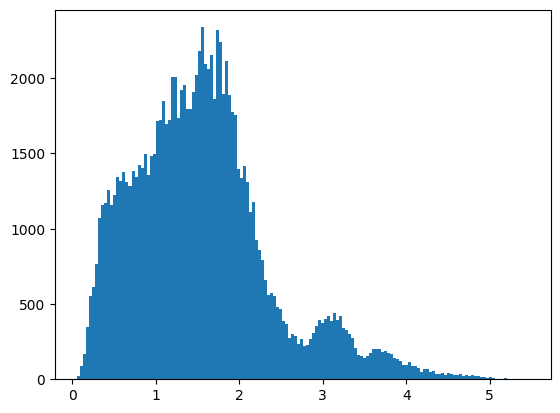

In [6]:
plt.hist (z, bins = 150)


## rejection sampling

In [16]:
bin, edges = np.histogram(z, bins = 200)


def rs(bin, edges, npoints):
    #calcolo il punto medio dei bins
    #normalizzo l'integrale
    x_mean = np.zeros(len(bin))
    area = 0
    for i in range (len(bin)):
        x_mean[i] = (edges[i + 1] - edges[i])
        area += x_mean[i] * bin[i]
        x_mean[i] = x_mean[i] / 2
    # print(x_mean.shape)
    x = []
    max_index = len(bin) 
    max_height = np.max(bin) / area
    while (len (x) < npoints):
        x_candidate = np.random.uniform(edges[0], edges[-1])
        y_candidate = np.random.uniform(0, max_height)
        for j in range (len (bin)):
            if (x_candidate >= edges[j] and x_candidate < edges[j + 1]):
                if (y_candidate < ( bin[j] / area)):
                    #accept the result
                    x.append( x_candidate )
    return x

(array([2.800e+01, 1.090e+02, 1.840e+02, 3.830e+02, 5.080e+02, 5.680e+02,
        8.160e+02, 1.076e+03, 1.125e+03, 1.129e+03, 1.084e+03, 1.012e+03,
        1.239e+03, 1.297e+03, 1.286e+03, 1.290e+03, 1.228e+03, 1.254e+03,
        1.315e+03, 1.327e+03, 1.401e+03, 1.351e+03, 1.287e+03, 1.360e+03,
        1.469e+03, 1.414e+03, 1.587e+03, 1.620e+03, 1.640e+03, 1.640e+03,
        1.640e+03, 1.971e+03, 1.910e+03, 1.761e+03, 1.725e+03, 1.895e+03,
        1.662e+03, 1.625e+03, 1.760e+03, 1.930e+03, 1.964e+03, 2.127e+03,
        1.910e+03, 1.989e+03, 1.952e+03, 1.726e+03, 2.135e+03, 2.140e+03,
        1.869e+03, 1.851e+03, 1.758e+03, 1.705e+03, 1.628e+03, 1.369e+03,
        1.288e+03, 1.244e+03, 1.190e+03, 1.085e+03, 1.056e+03, 9.010e+02,
        8.190e+02, 7.460e+02, 6.410e+02, 5.170e+02, 5.230e+02, 5.310e+02,
        4.740e+02, 4.360e+02, 4.010e+02, 3.300e+02, 2.480e+02, 3.020e+02,
        2.520e+02, 2.310e+02, 2.490e+02, 2.100e+02, 1.990e+02, 2.630e+02,
        2.730e+02, 3.300e+02, 4.230e+0

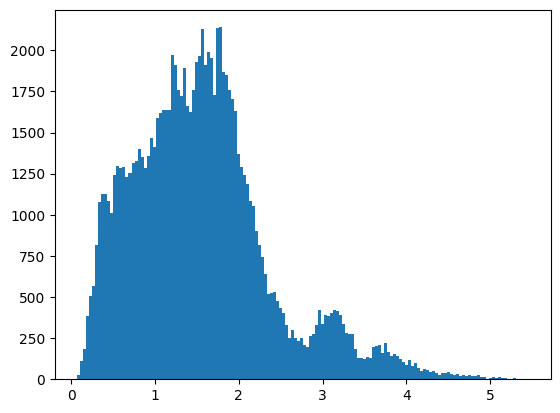

In [27]:
values = 100000
x = rs(bin, edges, values)
plt.hist(x, bins = 150)

## Inverse transform

In [35]:
def it(bin, edges, npoints):
    cdf = np.cumsum(bin) / np.sum(bin)  #summing (discrete integration) all the values to that point over normalization
    x_mean = np.zeros(len(bin))
    for i in range(len(bin)-1): 
        x_mean[i] =( edges[i + 1] + edges[i]) / 2
    unif_dist = np.random.uniform(0, 1, npoints)
    # print(unif_dist.shape, cdf.shape, x_mean.shape)
    new_x = np.interp(unif_dist, cdf, x_mean)
    return new_x


(array([4.400e+01, 7.600e+01, 1.100e+02, 2.270e+02, 3.070e+02, 4.200e+02,
        4.560e+02, 5.350e+02, 7.100e+02, 7.470e+02, 7.790e+02, 8.340e+02,
        8.890e+02, 7.970e+02, 8.640e+02, 8.070e+02, 8.770e+02, 9.330e+02,
        9.360e+02, 9.780e+02, 9.900e+02, 8.510e+02, 8.770e+02, 1.006e+03,
        9.250e+02, 9.780e+02, 1.060e+03, 1.045e+03, 1.050e+03, 9.890e+02,
        9.310e+02, 1.067e+03, 1.081e+03, 1.078e+03, 1.147e+03, 1.244e+03,
        1.221e+03, 1.223e+03, 1.219e+03, 1.191e+03, 1.264e+03, 1.396e+03,
        1.422e+03, 1.268e+03, 1.367e+03, 1.299e+03, 1.231e+03, 1.330e+03,
        1.282e+03, 1.254e+03, 1.329e+03, 1.451e+03, 1.450e+03, 1.555e+03,
        1.557e+03, 1.548e+03, 1.542e+03, 1.501e+03, 1.511e+03, 1.427e+03,
        1.334e+03, 1.510e+03, 1.571e+03, 1.519e+03, 1.431e+03, 1.405e+03,
        1.332e+03, 1.244e+03, 1.213e+03, 1.184e+03, 1.040e+03, 1.008e+03,
        9.480e+02, 9.650e+02, 9.900e+02, 8.800e+02, 8.340e+02, 7.500e+02,
        7.260e+02, 6.360e+02, 5.710e+0

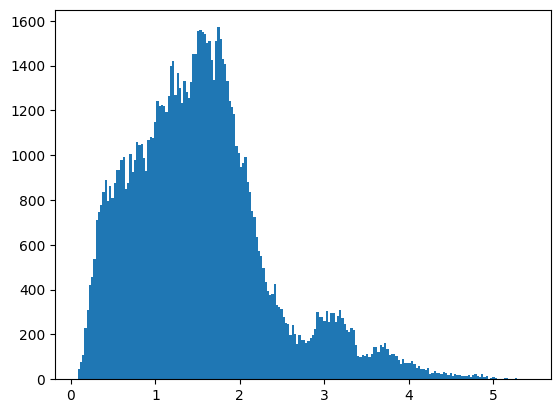

In [36]:
x1 = it(bin, edges, values)
plt.hist(x1, bins = 200)

## hist

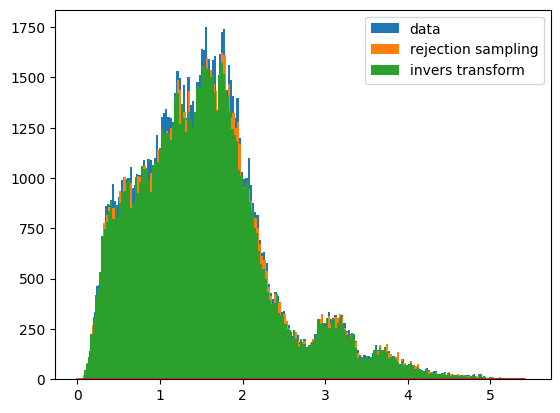

In [ ]:
plt.hist(z, bins = 200, label = 'data')
plt.hist(x, bins = 200, label = 'rejection sampling')
plt.hist(x1, bins = 200, label = 'invers transform')
plt.legend()